In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import preprocessing as pp
from src import model as md

import tensorflow as tf
from tensorflow import keras

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")

TensorFlow: 2.21.0
Keras:      3.12.2


In [2]:
# Re-run preprocessing — same logic as notebook 02
NAB_ROOT = PROJECT_ROOT / "data" / "raw" / "NAB"
CSV_PATH = NAB_ROOT / "data" / "realKnownCause" / "machine_temperature_system_failure.csv"
LABELS_FILE = NAB_ROOT / "labels" / "combined_windows.json"
TARGET_FILE = "realKnownCause/machine_temperature_system_failure.csv"

df = pp.load_nab_stream(CSV_PATH)
anomaly_windows = pp.load_anomaly_windows(LABELS_FILE, TARGET_FILE)

train_df, val_df, test_df = pp.split_by_time(df, pp.DEFAULT_SPLIT)
train_df_clean = pp.remove_anomaly_windows(train_df, anomaly_windows)

scaler = pp.fit_scaler(train_df_clean['value'].values)

X_train = pp.window_dataframe_by_segments(train_df_clean, scaler)
X_val   = pp.window_dataframe_by_segments(val_df,         scaler)
X_test  = pp.window_dataframe_by_segments(test_df,        scaler)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (13998, 60, 1)
X_val:   (517, 60, 1)
X_test:  (6751, 60, 1)


In [3]:
model = md.build_autoencoder(window_size=60, n_channels=1)
model = md.compile_autoencoder(model)
model.summary()

Model: "conv1d_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ window (InputLayer)                  │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 60, 16)              │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 30, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 30, 8)               │             392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 15, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 15, 8)               │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d (UpSampling1D)         │ (None, 30, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 30, 16)              │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d_1 (UpSampling1D)       │ (None, 60, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Conv1D)              │ (None, 60, 1)               │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,105 (4.32 KB)

 Trainable params: 1,105 (4.32 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
EPOCHS = 100
BATCH_SIZE = 128
PATIENCE = 10

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    X_train, X_train,                   # target = input — that's the whole trick
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2120 - mae: 0.2443 - val_loss: 0.0143 - val_mae: 0.0813 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0206 - mae: 0.0865 - val_loss: 0.0076 - val_mae: 0.0687 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0108 - mae: 0.0735 - val_loss: 0.0060 - val_mae: 0.0637 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0078 - mae: 0.0681 - val_loss: 0.0053 - val_mae: 0.0600 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0068 - mae: 0.0656 - val_loss: 0.0052 - val_mae: 0.0592 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0063 - mae: 0.0641 - val_loss: 0.0051 - val_mae: 0.0586 - learning_rate: 0.0010
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0059 - mae: 0.0629 - val_loss: 0.0050 - val_mae: 0.0581 - learning_rate: 0.001

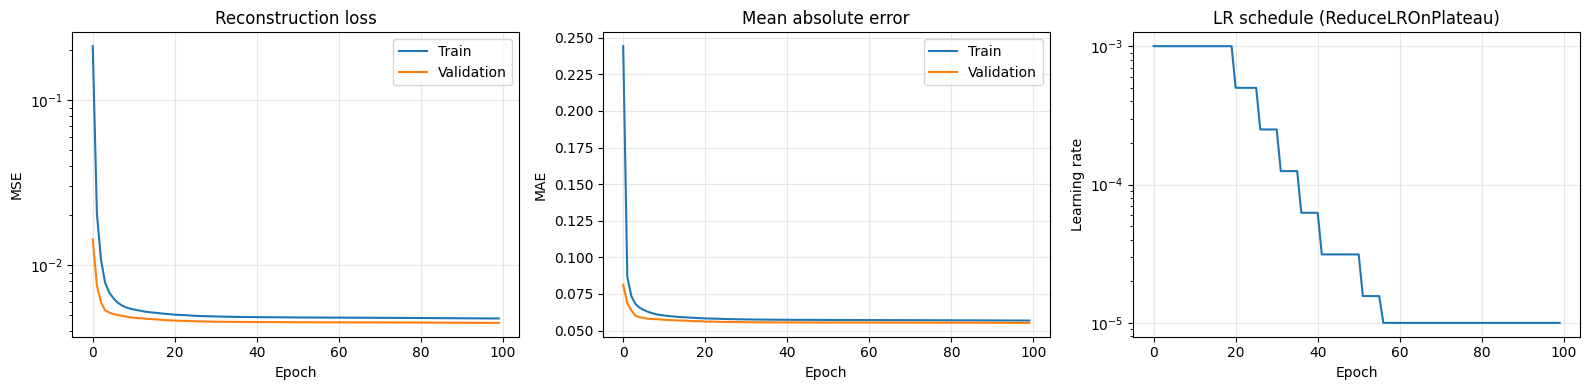

Best epoch: 100
Best val_loss: 0.004463


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MSE loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Reconstruction loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean absolute error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history.history['learning_rate'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning rate')
axes[2].set_title('LR schedule (ReduceLROnPlateau)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

In [6]:
model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "autoencoder_v1.keras"
model.save(model_path)
print(f"Model saved to {model_path}")
print(f"File size: {model_path.stat().st_size / 1024:.1f} KB")

Model saved to D:\dissertation\models\autoencoder_v1.keras
File size: 60.9 KB


In [7]:
# Compute per-window reconstruction errors for all three splits
err_train = md.reconstruction_error(model, X_train)
err_val   = md.reconstruction_error(model, X_val)
err_test  = md.reconstruction_error(model, X_test)

print(f"Train error:  mean={err_train.mean():.5f}  median={np.median(err_train):.5f}  max={err_train.max():.5f}")
print(f"Val error:    mean={err_val.mean():.5f}  median={np.median(err_val):.5f}  max={err_val.max():.5f}")
print(f"Test error:   mean={err_test.mean():.5f}  median={np.median(err_test):.5f}  max={err_test.max():.5f}")

Train error:  mean=0.00474  median=0.00459  max=0.02056
Val error:    mean=0.00446  median=0.00444  max=0.00559
Test error:   mean=0.00506  median=0.00473  max=0.05148


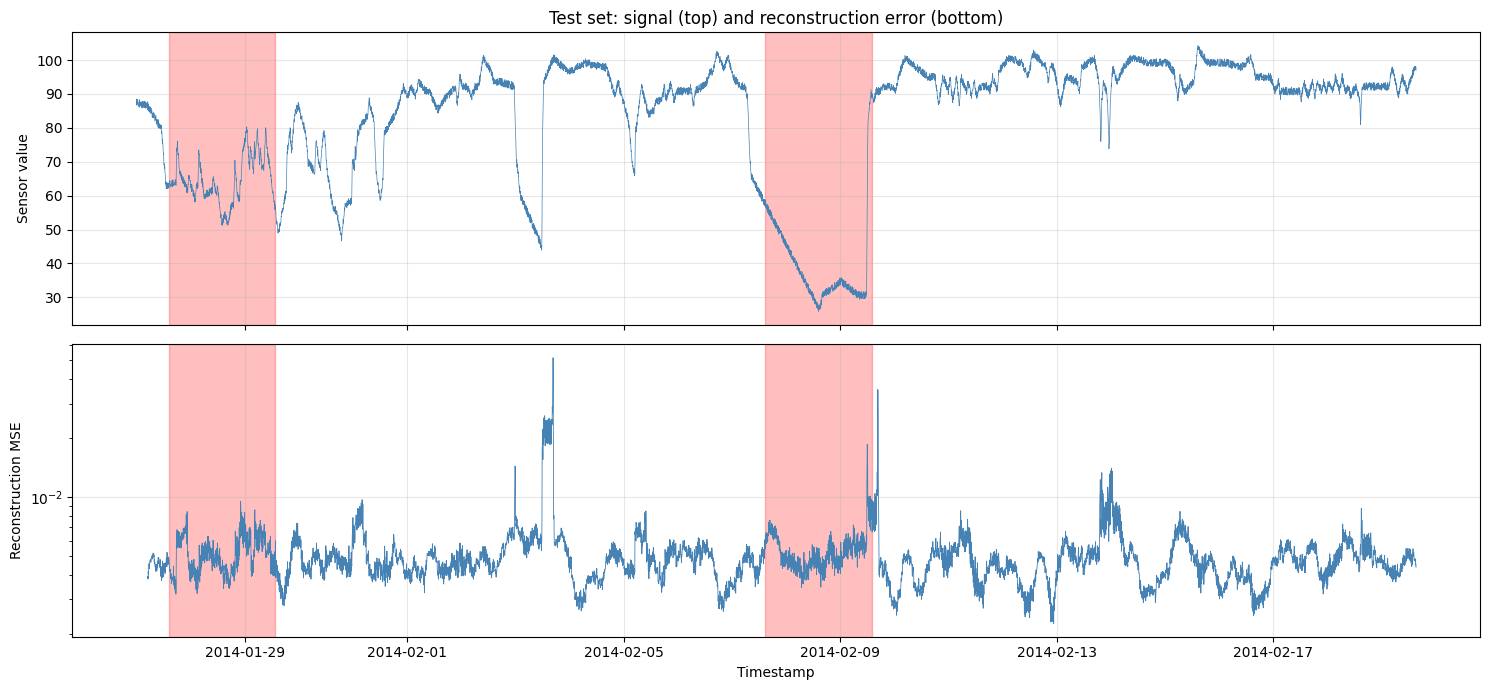

In [8]:
# Each test window's error corresponds to a starting position in the test data.
# Plot the error at the WINDOW'S END timestamp — that's "as of this time, what's
# the error of the window ending here", which is how real-time detection works.

test_timestamps = test_df['timestamp'].values
end_indices = np.arange(pp.WINDOW_SIZE - 1, pp.WINDOW_SIZE - 1 + len(err_test))
error_timestamps = test_timestamps[end_indices]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: original signal with anomaly windows shaded
axes[0].plot(test_df['timestamp'], test_df['value'], linewidth=0.5, color='steelblue')
for start, end in anomaly_windows:
    if start >= pp.DEFAULT_SPLIT.test_start and start < pp.DEFAULT_SPLIT.test_end:
        axes[0].axvspan(start, end, color='red', alpha=0.25)
axes[0].set_ylabel('Sensor value')
axes[0].set_title('Test set: signal (top) and reconstruction error (bottom)')
axes[0].grid(True, alpha=0.3)

# Bottom: reconstruction error over time
axes[1].plot(error_timestamps, err_test, linewidth=0.6, color='steelblue')
for start, end in anomaly_windows:
    if start >= pp.DEFAULT_SPLIT.test_start and start < pp.DEFAULT_SPLIT.test_end:
        axes[1].axvspan(start, end, color='red', alpha=0.25)
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Reconstruction MSE')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()